# 06-Finance Tutorial- Pricing Basket Options
### Modified for Quantum Rings toolkit for Qiskit 2.x

In [1]:
# This tutorial is from:
# https://qiskit-community.github.io/qiskit-finance/tutorials/06_basket_option_pricing.html

# Modified for use with Quantum Rings toolkit

In [2]:
#
# Setup your account
# You can also save your account locally using the class method QrRuntimeService.save_account(...) and
# invoke the QrRuntimeService class constructor without any arguments.
#

import os
my_token = os.environ["QR_TOKEN"]
my_name = os.environ["QR_ACCOUNT"]

#
# Set the backend of your choice, depending upon the task and your hardware configuration.
# See SDK documentation for additional help.
#

my_backend = "scarlet_quantum_rings"

In [3]:
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

%matplotlib inline
import numpy as np

from qiskit import QuantumRegister, QuantumCircuit, AncillaRegister, transpile
from qiskit_algorithms import IterativeAmplitudeEstimation, EstimationProblem
from qiskit.circuit.library import WeightedAdder, LinearAmplitudeFunction
#from qiskit_aer.primitives import Sampler
from qiskit_finance.circuit.library import LogNormalDistribution


from quantumrings.toolkit.qiskit import QrRuntimeService
from quantumrings.toolkit.qiskit import QrSamplerV2 as Sampler

#
# Acquire Quantum Rings Backend
#

qr_services = QrRuntimeService(name = my_name, token = my_token)
qr_backend = qr_services.backend(name = my_backend, precision = "single")

In [4]:
# number of qubits per dimension to represent the uncertainty
num_uncertainty_qubits = 2

# parameters for considered random distribution
S = 2.0  # initial spot price
vol = 0.4  # volatility of 40%
r = 0.05  # annual interest rate of 4%
T = 40 / 365  # 40 days to maturity

# resulting parameters for log-normal distribution
mu = (r - 0.5 * vol**2) * T + np.log(S)
sigma = vol * np.sqrt(T)
mean = np.exp(mu + sigma**2 / 2)
variance = (np.exp(sigma**2) - 1) * np.exp(2 * mu + sigma**2)
stddev = np.sqrt(variance)

# lowest and highest value considered for the spot price; in between, an equidistant discretization is considered.
low = np.maximum(0, mean - 3 * stddev)
high = mean + 3 * stddev

# map to higher dimensional distribution
# for simplicity assuming dimensions are independent and identically distributed)
dimension = 2
num_qubits = [num_uncertainty_qubits] * dimension
low = low * np.ones(dimension)
high = high * np.ones(dimension)
mu = mu * np.ones(dimension)
cov = sigma**2 * np.eye(dimension)

# construct circuit
u = LogNormalDistribution(num_qubits=num_qubits, mu=mu, sigma=cov, bounds=list(zip(low, high)))

<>:13: SyntaxWarning: invalid escape sequence '\$'
<>:14: SyntaxWarning: invalid escape sequence '\$'
<>:15: SyntaxWarning: invalid escape sequence '\%'
<>:13: SyntaxWarning: invalid escape sequence '\$'
<>:14: SyntaxWarning: invalid escape sequence '\$'
<>:15: SyntaxWarning: invalid escape sequence '\%'
C:\Users\vkasi\AppData\Local\Temp\ipykernel_46620\3600697497.py:13: SyntaxWarning: invalid escape sequence '\$'
  ax.set_xlabel("Spot Price $S_T^1$ (\$)", size=15)
C:\Users\vkasi\AppData\Local\Temp\ipykernel_46620\3600697497.py:14: SyntaxWarning: invalid escape sequence '\$'
  ax.set_ylabel("Spot Price $S_T^2$ (\$)", size=15)
C:\Users\vkasi\AppData\Local\Temp\ipykernel_46620\3600697497.py:15: SyntaxWarning: invalid escape sequence '\%'
  ax.set_zlabel("Probability (\%)", size=15)


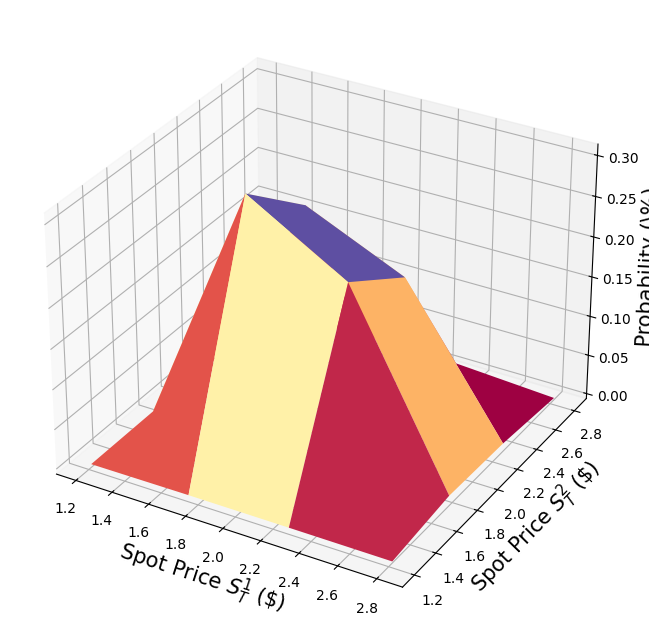

In [5]:
# plot PDF of uncertainty model
x = [v[0] for v in u.values]
y = [v[1] for v in u.values]
z = u.probabilities
# z = map(float, z)
# z = list(map(float, z))
resolution = np.array([2**n for n in num_qubits]) * 1j
grid_x, grid_y = np.mgrid[min(x) : max(x) : resolution[0], min(y) : max(y) : resolution[1]]
grid_z = griddata((x, y), z, (grid_x, grid_y))
plt.figure(figsize=(10, 8))
ax = plt.axes(projection="3d")
ax.plot_surface(grid_x, grid_y, grid_z, cmap=plt.cm.Spectral)
ax.set_xlabel("Spot Price $S_T^1$ (\$)", size=15)
ax.set_ylabel("Spot Price $S_T^2$ (\$)", size=15)
ax.set_zlabel("Probability (\%)", size=15)
plt.show()

In [6]:
# determine number of qubits required to represent total loss
weights = []
for n in num_qubits:
    for i in range(n):
        weights += [2**i]

# create aggregation circuit
agg = WeightedAdder(sum(num_qubits), weights)
n_s = agg.num_sum_qubits
n_aux = agg.num_qubits - n_s - agg.num_state_qubits  # number of additional qubits

In [7]:
# set the strike price (should be within the low and the high value of the uncertainty)
strike_price = 3.5

# map strike price from [low, high] to {0, ..., 2^n-1}
max_value = 2**n_s - 1
low_ = low[0]
high_ = high[0]
mapped_strike_price = (
    (strike_price - dimension * low_) / (high_ - low_) * (2**num_uncertainty_qubits - 1)
)

# set the approximation scaling for the payoff function
c_approx = 0.25

# setup piecewise linear objective fcuntion
breakpoints = [0, mapped_strike_price]
slopes = [0, 1]
offsets = [0, 0]
f_min = 0
f_max = 2 * (2**num_uncertainty_qubits - 1) - mapped_strike_price
basket_objective = LinearAmplitudeFunction(
    n_s,
    slopes,
    offsets,
    domain=(0, max_value),
    image=(f_min, f_max),
    rescaling_factor=c_approx,
    breakpoints=breakpoints,
)

C:\Users\vkasi\AppData\Local\Temp\ipykernel_46620\2529205002.py:21: DeprecationWarning: The class ``qiskit.circuit.library.arithmetic.linear_amplitude_function.LinearAmplitudeFunction`` is deprecated as of Qiskit 2.2. It will be removed in Qiskit 3.0. Use the class qiskit.circuit.library.LinearAmplitudeFunctionGate instead.
  basket_objective = LinearAmplitudeFunction(


In [8]:
# define overall multivariate problem
qr_state = QuantumRegister(u.num_qubits, "state")  # to load the probability distribution
qr_obj = QuantumRegister(1, "obj")  # to encode the function values
ar_sum = AncillaRegister(n_s, "sum")  # number of qubits used to encode the sum
ar = AncillaRegister(max(n_aux, basket_objective.num_ancillas), "work")  # additional qubits

objective_index = u.num_qubits

basket_option = QuantumCircuit(qr_state, qr_obj, ar_sum, ar)
basket_option.append(u, qr_state)
basket_option.append(agg, qr_state[:] + ar_sum[:] + ar[:n_aux])
basket_option.append(basket_objective, ar_sum[:] + qr_obj[:] + ar[: basket_objective.num_ancillas])

print(basket_option.draw())
print("objective qubit index", objective_index)

         ┌───────┐┌────────┐      
state_0: ┤0      ├┤0       ├──────
         │       ││        │      
state_1: ┤1      ├┤1       ├──────
         │  P(X) ││        │      
state_2: ┤2      ├┤2       ├──────
         │       ││        │      
state_3: ┤3      ├┤3       ├──────
         └───────┘│        │┌────┐
    obj: ─────────┤        ├┤3   ├
                  │        ││    │
  sum_0: ─────────┤4 adder ├┤0   ├
                  │        ││    │
  sum_1: ─────────┤5       ├┤1   ├
                  │        ││    │
  sum_2: ─────────┤6       ├┤2 F ├
                  │        ││    │
 work_0: ─────────┤7       ├┤4   ├
                  │        ││    │
 work_1: ─────────┤8       ├┤5   ├
                  │        ││    │
 work_2: ─────────┤9       ├┤6   ├
                  └────────┘└────┘
objective qubit index 4


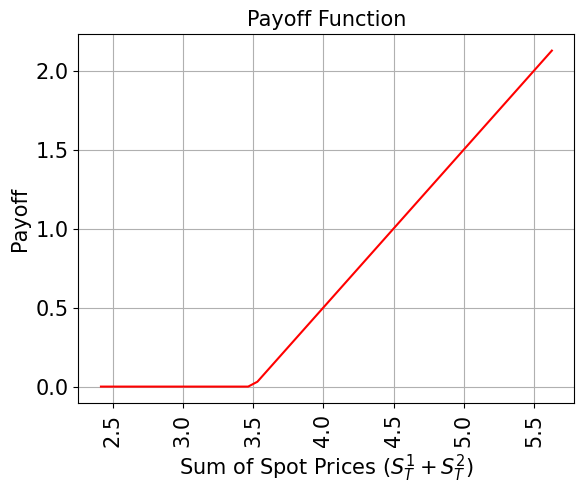

In [9]:
# plot exact payoff function (evaluated on the grid of the uncertainty model)
x = np.linspace(sum(low), sum(high))
y = np.maximum(0, x - strike_price)
plt.plot(x, y, "r-")
plt.grid()
plt.title("Payoff Function", size=15)
plt.xlabel("Sum of Spot Prices ($S_T^1 + S_T^2)$", size=15)
plt.ylabel("Payoff", size=15)
plt.xticks(size=15, rotation=90)
plt.yticks(size=15)
plt.show()

In [10]:
# evaluate exact expected value
sum_values = np.sum(u.values, axis=1)
exact_value = np.dot(
    u.probabilities[sum_values >= strike_price],
    sum_values[sum_values >= strike_price] - strike_price,
)
print("exact expected value:\t%.4f" % exact_value)

exact expected value:	0.4870


In [11]:
num_state_qubits = basket_option.num_qubits - basket_option.num_ancillas
print("state qubits: ", num_state_qubits)
transpiled = transpile(basket_option, basis_gates=["u", "cx"])
print("circuit width:", transpiled.width())
print("circuit depth:", transpiled.depth())

state qubits:  5
circuit width: 11
circuit depth: 384


In [12]:
#
# Note: The pub is encapsulated inside a [] in the call to the run method below.
#

basket_option_measure = basket_option.measure_all(inplace=False)
sampler = Sampler(backend = qr_backend)
job = sampler.run([basket_option_measure])

In [13]:
# Quasi distribution is not supported in SamplerV2
# Here is a workaround
from qiskit.result import QuasiDistribution
result = job.result()
pub_result = result[0]
counts = pub_result.data.meas.get_counts()
shots = 0
for key, val in counts.items():
    shots += val
quasi_dist = QuasiDistribution({outcome: freq / shots for outcome, freq in counts.items()})

# evaluate the result
value = 0
probabilities = quasi_dist.binary_probabilities()
for i, prob in probabilities.items():
    if prob > 1e-4 and i[-num_state_qubits:][0] == "1":
        value += prob


# map value to original range
mapped_value = (
    basket_objective.post_processing(value) / (2**num_uncertainty_qubits - 1) * (high_ - low_)
)
print("Exact Operator Value:  %.4f" % value)
print("Mapped Operator value: %.4f" % mapped_value)
print("Exact Expected Payoff: %.4f" % exact_value)

Exact Operator Value:  0.5127
Mapped Operator value: 1.1321
Exact Expected Payoff: 0.4870


In [14]:
# Example output:

# Exact Operator Value:  0.4678
# Mapped Operator value: 0.8888
# Exact Expected Payoff: 0.4870

In [15]:
# set target precision and confidence level
epsilon = 0.01
alpha = 0.05

problem = EstimationProblem(
    state_preparation=basket_option,
    objective_qubits=[objective_index],
    post_processing=basket_objective.post_processing,
)
# construct amplitude estimation
ae = IterativeAmplitudeEstimation(
    epsilon_target=epsilon, alpha=alpha, sampler=Sampler(backend = qr_backend, options={"shots": 100, "seed": 75})
)

In [16]:
result = ae.estimate(problem)

In [17]:
conf_int = (
    np.array(result.confidence_interval_processed)
    / (2**num_uncertainty_qubits - 1)
    * (high_ - low_)
)
print("Exact value:        \t%.4f" % exact_value)
print(
    "Estimated value:    \t%.4f"
    % (result.estimation_processed / (2**num_uncertainty_qubits - 1) * (high_ - low_))
)
print("Confidence interval:\t[%.4f, %.4f]" % tuple(conf_int))

Exact value:        	0.4870
Estimated value:    	1.0218
Confidence interval:	[1.0089, 1.0346]


In [18]:
# Example output:

# Exact value:        	0.4870
# Estimated value:    	1.0976
# Confidence interval:	[1.0698, 1.1254]

In [19]:
import tutorial_magics

%qiskit_version_table
%quantumrings_version_table
%qiskit_copyright

Software,Version
QuantumRingsLib,0.11.0
quantumrings-toolkit-qiskit,0.1.10
